In [1]:
import sys
print(sys.executable)

%pip install -U pandas gprofiler-official ipykernel

/usr/local/bin/python3.10
Note: you may need to restart the kernel to use updated packages.


In [2]:

from gprofiler import GProfiler
import pandas as pd

gene_list = ["TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
"SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
"CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2"]

print(len(gene_list))
print(gene_list)

gp = GProfiler()
results = gp.profile(gene_list, organism="hsapiens", no_evidences=False) #no_evidences=False is set to show intersections
results = pd.DataFrame(results)
print(results.shape)

results.head()

23
['TP53', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'GADD45A', 'GADD45B', 'SESN1', 'SESN2', 'RRM2B', 'DRAM1', 'FAS', 'TNFRSF10B', 'APAF1', 'CASP3', 'CASP9', 'CYCS', 'PTEN', 'ATM', 'ATR', 'BRCA1', 'BRCA2']
(608, 16)


,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,p53 signaling pathway,8484,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,5.941134e-39,[KEGG:00000],0.909091,query_1,22,0.270270,True,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,8.715110e-36,[WP:000000],0.826087,query_1,23,0.275362,True,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
2,miRNA regulation of DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.994203e-35,[WP:000000],0.826087,query_1,23,0.260274,True,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
3,Platinum drug resistance,8484,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.175199e-20,[KEGG:00000],0.590909,query_1,22,0.180556,True,KEGG,72,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
4,miRNA regulation of p53 pathway in prostate ca...,8752,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.706305e-20,[WP:000000],0.478261,query_1,23,0.354839,True,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."


In [4]:
import sys
print(sys.executable)
!{sys.executable} -m pip install sentence-transformers scikit-learn

/usr/local/bin/python3.10
  Using cached sentence_transformers-5.4.0-py3-none-any.whl.metadata (17 kB)
  Using cached transformers-5.5.3-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.10.1-py3-none-any.whl.metadata (14 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using 

In [ ]:
%pip install scipy
import sys
sys.path.append("/Users/abdulazizalshujaa/Desktop/CrossEnrich/src")

from crossenrich.standardization import (standardize_results_frame, split_by_source)

frame = standardize_results_frame(results)
columns = ["description", "name"]
#, "intersections", "name", "p_value", "canonical_source", "rank_within_source", "term_tokens", "standardized_name", "parent_terms"
#frame[columns].head()

#display(frame[columns].head(200))
line = frame.loc[196]
print("Name", line["name"])
print("Description", line["description"])
#dict_frame = split_by_source(frame)
#frame_source = pd.DataFrame()
#for source, frame in dict_frame.items():
 #   print(f"{source}")




Note: you may need to restart the kernel to use updated packages.
Name response to chemical
Description "Any process that results in a change in state or activity of a cell or an organism (in terms of movement, secretion, enzyme production, gene expression, etc.) as a result of a chemical stimulus." [GOC:jl]


In [19]:
import importlib
import crossenrich.semantic as semantic
importlib.reload(semantic)

from crossenrich.semantic import (build_semantic_similarity_matrix, cluster_terms, build_cluster_consistency_matrix)

semantic_similarity = frame.copy()
semantic_similarity = build_semantic_similarity_matrix(semantic_similarity)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 30029.38it/s]
BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
%pip install -U matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Term-term similarity matrix:


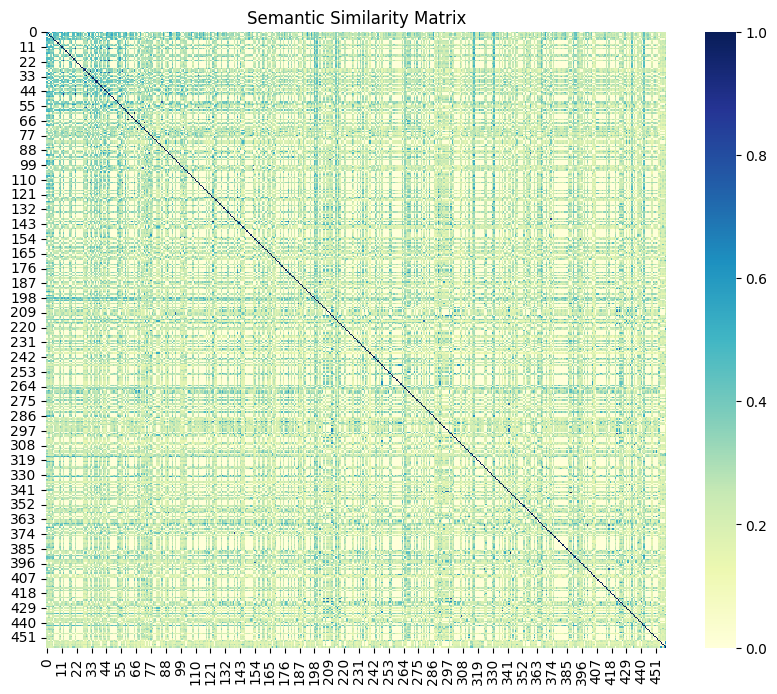

,0,1,2,3,4,5,6,7,8,9,...,449,450,451,452,453,454,455,456,457,458
0,1.00,0.53,0.53,0.00,0.55,0.52,0.52,0.40,0.39,0.53,...,0.24,0.29,0.22,0.21,0.20,0.23,0.22,0.21,0.21,0.21
1,0.53,1.00,0.00,0.44,0.00,0.48,0.44,0.46,0.46,0.00,...,0.18,0.26,0.23,0.26,0.00,0.22,0.22,0.21,0.21,0.21
2,0.53,0.00,1.00,0.43,0.00,0.55,0.45,0.45,0.45,0.00,...,0.23,0.26,0.22,0.29,0.00,0.28,0.21,0.22,0.22,0.20
3,0.00,0.44,0.43,1.00,0.42,0.39,0.44,0.36,0.36,0.29,...,0.20,0.31,0.22,0.20,0.20,0.20,0.19,0.21,0.18,0.18
4,0.55,0.00,0.00,0.42,1.00,0.44,0.48,0.39,0.38,0.00,...,0.29,0.36,0.23,0.29,0.00,0.28,0.20,0.25,0.23,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,0.23,0.22,0.28,0.20,0.28,0.00,0.20,0.25,0.24,0.26,...,0.20,0.19,0.20,0.23,0.16,1.00,0.00,0.00,0.00,0.60
455,0.22,0.22,0.21,0.19,0.20,0.00,0.18,0.22,0.21,0.24,...,0.16,0.15,0.16,0.17,0.17,0.00,1.00,0.00,0.00,0.62
456,0.21,0.21,0.22,0.21,0.25,0.00,0.26,0.24,0.23,0.16,...,0.18,0.23,0.20,0.19,0.15,0.00,0.00,1.00,0.00,0.21
457,0.21,0.21,0.22,0.18,0.23,0.00,0.21,0.23,0.23,0.24,...,0.17,0.18,0.19,0.19,0.15,0.00,0.00,0.00,1.00,0.59


In [31]:

import matplotlib.pyplot as plt
import seaborn as sns

print("Term-term similarity matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(semantic_similarity, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Matrix")
plt.show()
display(semantic_similarity.round(2))

In [15]:
import numpy as np
sim = semantic_similarity.copy()

print("min sim:", np.nanmin(sim.to_numpy()))
print("max sim:", np.nanmax(sim.to_numpy()))
print("any > 1:", (sim.to_numpy() > 1).any())
print("any NaN:", np.isnan(sim.to_numpy()).any())

min sim: 0.0
max sim: 1.0000000298023224
any > 1: True
any NaN: False


In [35]:
cluster = cluster_terms(frame, similarity_threshold=0.4)
cluster_consistency = build_cluster_consistency_matrix(cluster)

In [36]:
print("Clustered term table:")
display(
    cluster[[
        "canonical_source",
        "name",
        "standardized_name",
        "cluster_id",
        "cluster_label",
        "semantic_similarity_max",
    ]].sort_values(["cluster_id", "canonical_source"])
)

Clustered term table:


,canonical_source,name,standardized_name,cluster_id,cluster_label,semantic_similarity_max
278,GO:BP,mitochondrial DNA metabolic process,mitochondrial dna metabolic process,0,tp53 regulates metabolic genes,0.478323
183,REAC,TP53 Regulates Metabolic Genes,tp53 regulates metabolic genes,0,tp53 regulates metabolic genes,0.478323
318,GO:BP,mitochondrial genome maintenance,mitochondrial genome maintenance,1,mitochondrial genome maintenance,0.417708
223,GO:BP,cellular response to amino acid starvation,cellular response to amino acid starvation,2,cellular response to amino acid starvation,0.475451
355,REAC,Cellular response to chemical stress,cellular response to chemical stress,2,cellular response to amino acid starvation,0.475451
...,...,...,...,...,...,...
402,GO:BP,cellular response to hypoxia,cellular response to hypoxia,281,cellular response to hypoxia,0.478324
282,GO:BP,response to reactive oxygen species,response to reactive oxygen species,282,response to reactive oxygen species,0.392025
229,GO:BP,G2/M transition of mitotic cell cycle,g2 m transition of mitotic cell cycle,283,g2 m transition of mitotic cell cycle,0.501151
235,GO:BP,"positive regulation of DNA damage response, si...",positive regulation of dna damage response sig...,284,positive regulation of dna damage response sig...,0.482069


Database-level cluster consistency matrix:


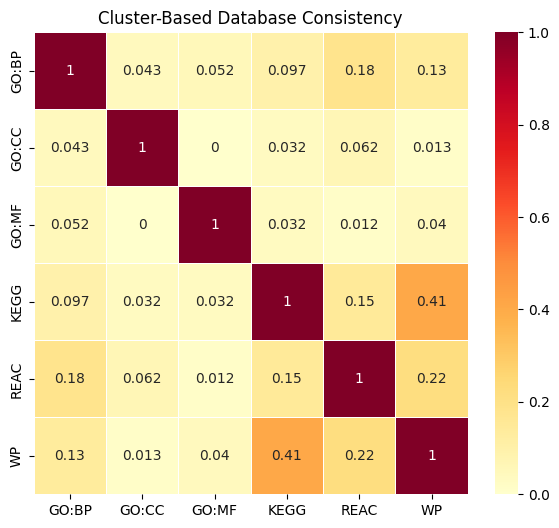

,GO:BP,GO:CC,GO:MF,KEGG,REAC,WP
GO:BP,1.00,0.04,0.05,0.10,0.18,0.13
GO:CC,0.04,1.00,0.00,0.03,0.06,0.01
GO:MF,0.05,0.00,1.00,0.03,0.01,0.04
KEGG,0.10,0.03,0.03,1.00,0.15,0.41
REAC,0.18,0.06,0.01,0.15,1.00,0.22
WP,0.13,0.01,0.04,0.41,0.22,1.00


In [37]:
print("Database-level cluster consistency matrix:")
plt.figure(figsize=(7, 6))
sns.heatmap(
    cluster_consistency,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Cluster-Based Database Consistency")
plt.show()
display(cluster_consistency.round(2))